In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
RAW_PATH = f"{PROJECT_PATH}/data/processed/IT24102697_transformed(5th).csv"

# Load dataset
df = pd.read_csv(RAW_PATH)
print("Dataset loaded:", df.shape)
df.head()

Mounted at /content/drive
Dataset loaded: (1025, 13)


,cholesterol,max_heart_rate,thalassemia,chest_pain_type,st_depression,num_major_vessels,exercise_angina,resting_bp,age,st_slope,sex,resting_ecg,heart_disease
0,-0.659332,0.821321,1.089852,-0.915755,-0.060888,1.209221,-0.712287,-0.377636,-0.268437,0.995433,0.661504,0.891255,0
1,-0.833861,0.255968,1.089852,-0.915755,1.727137,-0.731971,1.403928,0.479107,-0.158157,-2.243675,0.661504,-1.004049,0
2,-1.396233,-1.048692,1.089852,-0.915755,1.301417,-0.731971,1.403928,0.764688,1.716595,-2.243675,0.661504,0.891255,0
3,-0.833861,0.516900,1.089852,-0.915755,-0.912329,0.238625,-0.712287,0.936037,0.724079,0.995433,0.661504,0.891255,0
4,0.930822,-1.874977,-0.522122,-0.915755,0.705408,1.694519,-0.712287,0.364875,0.834359,-0.624121,-1.511706,0.891255,0


Feature correlation with heart disease:
 heart_disease        1.000000
chest_pain_type      0.434854
max_heart_rate       0.423445
st_slope             0.345512
resting_ecg          0.134468
cholesterol         -0.118254
resting_bp          -0.132301
age                 -0.229324
sex                 -0.279501
thalassemia         -0.345187
num_major_vessels   -0.432324
exercise_angina     -0.438029
st_depression       -0.442847
Name: heart_disease, dtype: float64
Most predictive features: ['chest_pain_type', 'max_heart_rate', 'st_slope', 'resting_ecg', 'resting_bp', 'age', 'sex', 'thalassemia', 'num_major_vessels', 'exercise_angina', 'st_depression']
Final dataset shape: (1025, 12)


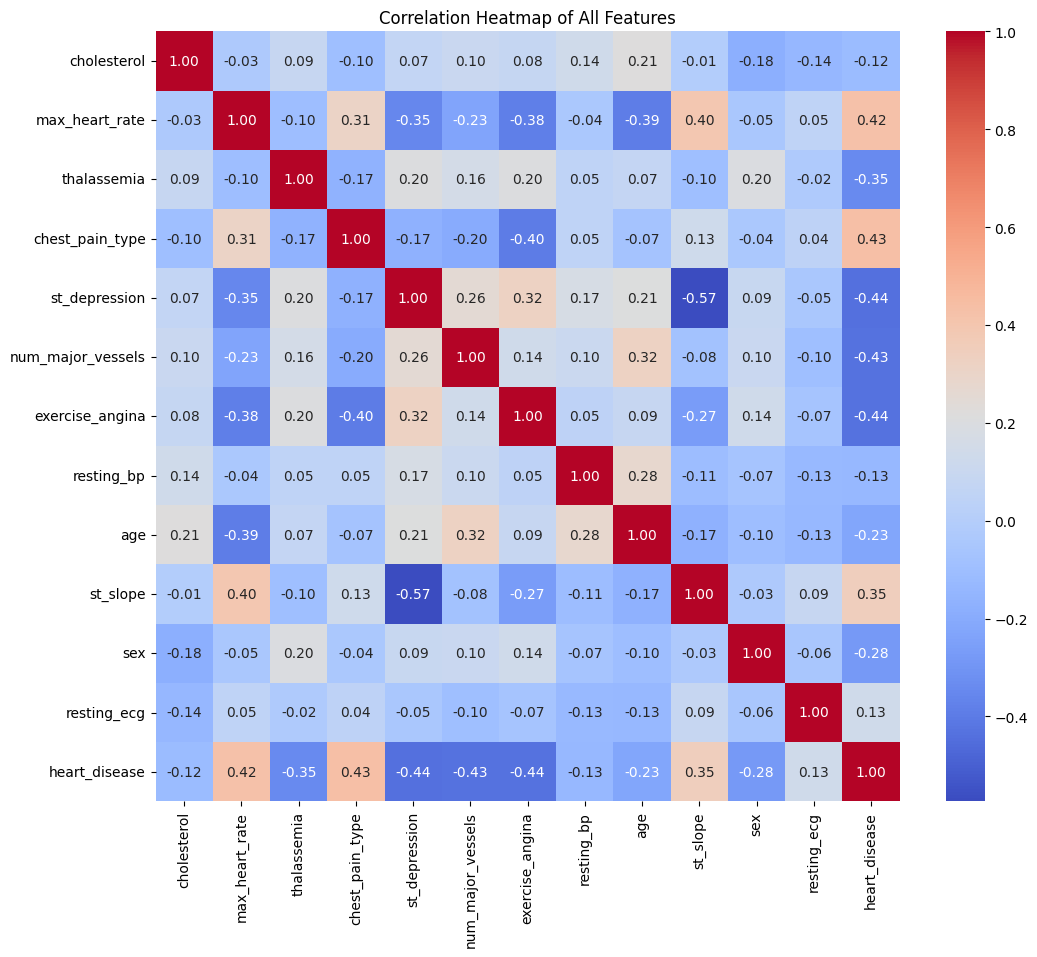

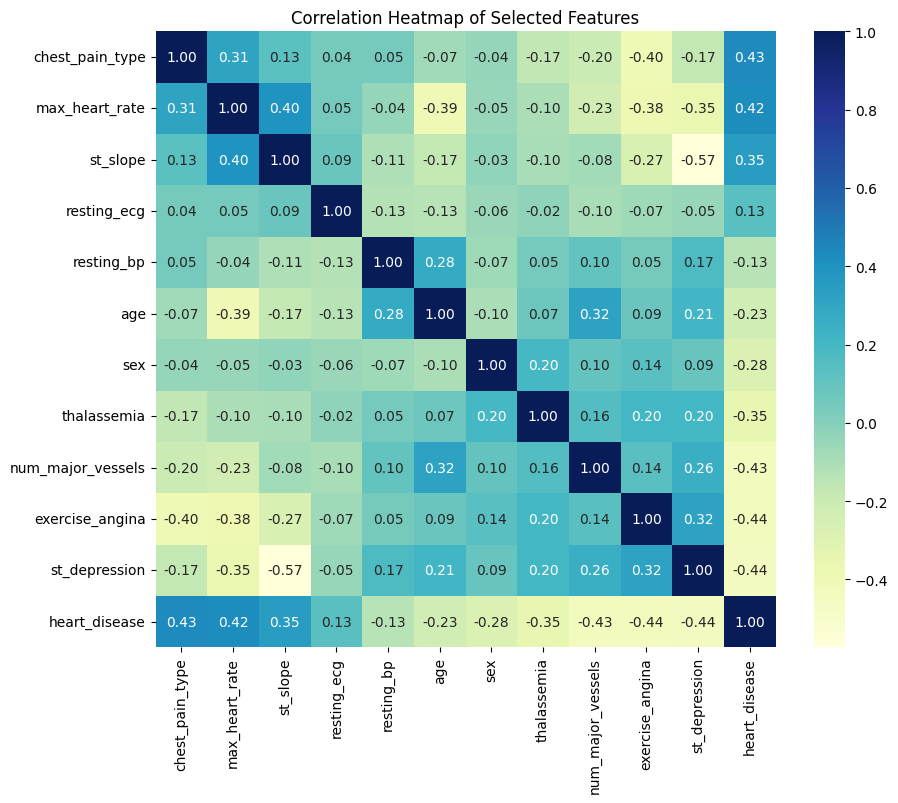

In [2]:
# Correlation thresholding

# Compute correlation of features with target
target_corr = df.corr()['heart_disease'].sort_values(ascending=False)
print("Feature correlation with heart disease:\n", target_corr)

# Keep only features with correlation > 0.12
important_features = target_corr[abs(target_corr) > 0.12].index.tolist()
important_features.remove('heart_disease')  # remove target itself
print("Most predictive features:", important_features)

# Final dataset with selected features + target
df_final = df[important_features + ['heart_disease']].copy()
print("Final dataset shape:", df_final.shape)

# Correlation heatmap for all features
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of All Features")
plt.show()

# Correlation heatmap for final selected features
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df_final.corr(), annot=True, cmap="YlGnBu", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap of Selected Features")
plt.show()

In [3]:
# Define save folder
SAVE_FOLDER = os.path.join(PROJECT_PATH, "results/eda_visualizations/Correlation_thresholding")
os.makedirs(SAVE_FOLDER, exist_ok=True)

#  Save plots
plot_path = os.path.join(SAVE_FOLDER, "correlation_heatmap_all_features.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Saved plot: {plot_path}")

plot_path = os.path.join(SAVE_FOLDER, "correlation_heatmap_selected_features.png")
fig.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"Saved plot: {plot_path}")

Saved plot: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/Correlation_thresholding/correlation_heatmap_all_features.png
Saved plot: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/eda_visualizations/Correlation_thresholding/correlation_heatmap_selected_features.png


In [4]:
# Save updated dataset

PROC_PATH = os.path.join(PROJECT_PATH, "data/processed/IT24102706_correlation_thresholding(6th).csv")
os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
df_final.to_csv(PROC_PATH, index=False)
print("Saved final selected dataset to:", PROC_PATH)

Saved final selected dataset to: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/data/processed/IT24102706_correlation_thresholding(6th).csv


In [5]:
# Define paths
PROJECT_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01"
OUTPUT_FOLDER = os.path.join(PROJECT_PATH, "results/output")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Final dataset
FINAL_DATA_PATH = os.path.join(OUTPUT_FOLDER, "heart_dataset_final.csv")

df_final.to_csv(FINAL_DATA_PATH, index=False)
print(f"Final dataset saved successfully at: {FINAL_DATA_PATH}")
print("Shape of saved dataset:", df_final.shape)


Final dataset saved successfully at: /content/drive/MyDrive/2025-Y2-S1-MLB-B11G1-01/results/output/heart_dataset_final.csv
Shape of saved dataset: (1025, 12)
